C:\Users\17934\AppData\Local\Temp\ipykernel_4860\1502395123.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


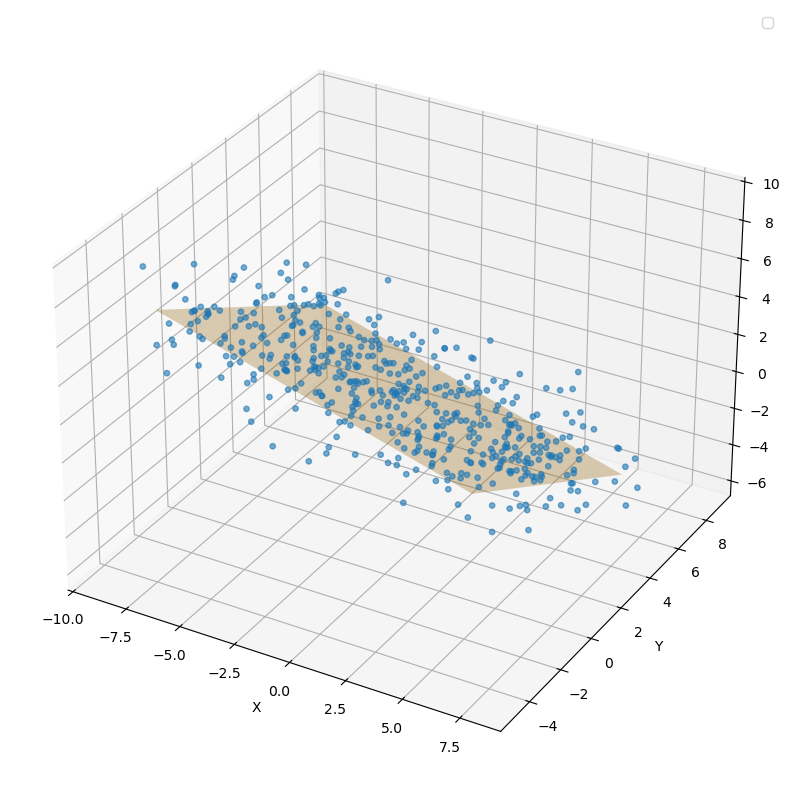

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ====================== 超参 ======================
n_points = 500        # 数据点数量
noise_mean = 0.0
noise_std = 1.0        # 标准差=1，方差=1

# ====================== 生成平面上无噪声点 ======================
# 平面方程变形：z = (6 - x - 2y) / 3
x = np.random.uniform(-8, 6, size=n_points)
y = np.random.uniform(-3, 7, size=n_points)
z = (6 - x - 2 * y) / 3

# 各维度添加高斯噪声
x_data = x + np.random.normal(noise_mean, noise_std, n_points)
y_data = y + np.random.normal(noise_mean, noise_std, n_points)
z_data = z + np.random.normal(noise_mean, noise_std, n_points)

# ====================== 绘图 ======================
fig = plt.figure(figsize=(10, 8))
ax: Axes3D = fig.add_subplot(111, projection="3d")

# 带噪声散点
ax.scatter(x_data, y_data, z_data, c="#1f77b4", alpha=0.6, s=15)

# 绘制理想平面网格
xx, yy = np.meshgrid(np.linspace(-8, 6, 35),
                     np.linspace(-3, 7, 35))
zz = (6 - xx - 2 * yy) / 3
ax.plot_surface(xx, yy, zz, color="orange", alpha=0.3)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.tight_layout()
plt.show()

# 如果需要把数据集导出备用
data = np.column_stack([x_data, y_data, z_data])


PCA 降维本质：把中心化的数据集投影到前 d 个主成分定义的超平面上
选择的超平面要尽可能保持原数据的方差

$$X_d = XW_d$$

In [2]:
data_centered = data - data.mean(axis=0)
U, s, Vt = np.linalg.svd(data_centered) # s: 奇异值，用来判断每个方向携带信息量多少
                                        # Vt: 右奇异矩阵，每一行是一个主成分方向
n = data_centered.shape[0]
explained_variance = s**2 / (n-1)
explained_variance_ratio = explained_variance / explained_variance.sum()

print("奇异值",s)
print("各方向方差占比：", explained_variance_ratio)
print("奇异矩阵",Vt)

奇异值 [104.93004757  78.05599271  22.82532629]
各方向方差占比： [0.62473245 0.34570593 0.02956163]
奇异矩阵 [[-0.8663597  -0.22957657  0.44352618]
 [ 0.42652652 -0.80210785  0.41796906]
 [-0.25979992 -0.55128722 -0.79283441]]


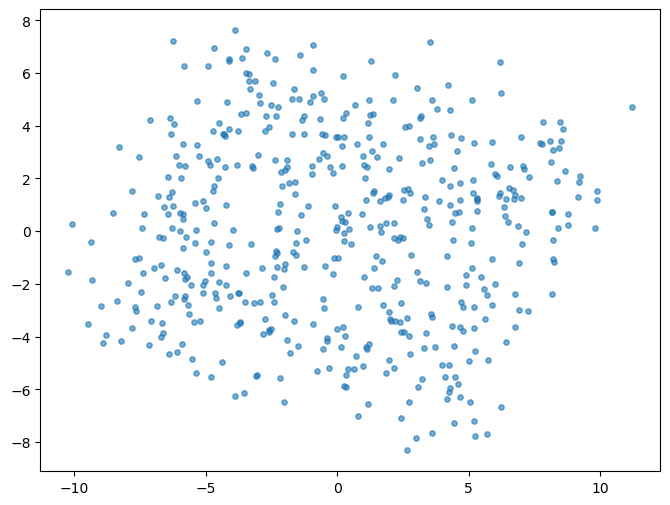

In [3]:
W = Vt[:2].T
data_2d = data_centered @ W

plt.figure(figsize=(8,6))
plt.scatter(data_2d[:,0], data_2d[:,1], alpha=0.6, s=15)

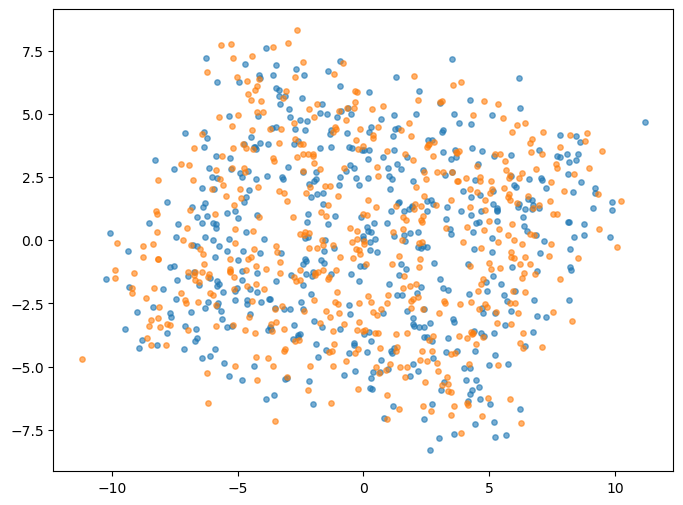

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
new_data_2d = pca.fit_transform(data)

plt.figure(figsize=(8,6))
plt.scatter(data_2d[:,0], data_2d[:,1], alpha=0.6, s=15)
plt.scatter(new_data_2d[:,0], new_data_2d[:,1], alpha=0.6, s=15)

In [5]:
print(pca.explained_variance_ratio_)

[0.62473245 0.34570593]


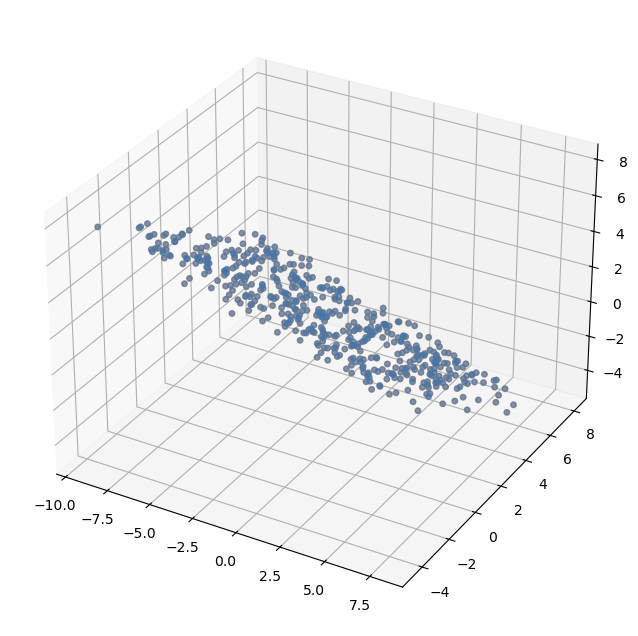

In [10]:
data_recovered = data_2d @ W.T + data.mean(axis=0)
new_data_recovered = pca.inverse_transform(new_data_2d)

fig = plt.figure(figsize=(10, 8))
ax: Axes3D = fig.add_subplot(111, projection="3d")

ax.scatter(data_recovered[:,0], data_recovered[:,1], data_recovered[:,2], c="#4477AA", alpha=0.6, s=15)
ax.scatter(new_data_recovered[:,0], new_data_recovered[:,1], new_data_recovered[:,2], c="#DD8855", alpha=0.6, s=15)